<a href="https://colab.research.google.com/github/Rurisruring/aoi-defect-classification/blob/main/notebook/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf /content/data

In [ ]:
# google drive 權限
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# clone git
! git clone https://github.com/Rurisruring/aoi-defect-classification.git
%cd aoi-defect-classification

Cloning into 'aoi-defect-classification'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 2), reused 9 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 6.82 KiB | 6.82 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/aoi-defect-classification/aoi-defect-classification


In [ ]:
# 複製訓練資料到本機磁碟
import os, time

DRIVE_DATA = '/content/drive/MyDrive/aoi_data'
LOCAL_DATA = '/content/data'

if not os.path.exists(LOCAL_DATA):
    os.makedirs(LOCAL_DATA)
    t0 = time.time()
    !cp {DRIVE_DATA}/train.csv {DRIVE_DATA}/test.csv {LOCAL_DATA}/
    !cp -r {DRIVE_DATA}/train_images {LOCAL_DATA}/
    print(f'複製完成,耗時 {time.time()-t0:.0f} 秒')
else:
    print('本機資料已存在,跳過複製')

!ls {LOCAL_DATA}
!echo "train_images 張數:" && ls {LOCAL_DATA}/train_images | wc -l

複製完成,耗時 1397 秒
test.csv  train.csv  train_images
train_images 張數:
2528


In [ ]:
n = len(os.listdir('/content/data/train_images'))
print('影像數:', n)
assert n >= 2528, f'影像不足,只有 {n} 張,複製可能沒完成'
print('OK,資料完整')

影像數: 2528
OK,資料完整


In [ ]:
# 讓python找得到src
import sys
sys.path.append('/content/aoi-defect-classification')
import torch
print('PyTorch: ', torch.__version__)
print('CUDA available: ', torch.cuda.is_available())
print('GPU: ', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')

PyTorch:  2.11.0+cu128
CUDA available:  True
GPU:  Tesla T4


In [ ]:
# 檢查檔案狀態、Label的分佈情況
# Label：瑕疵分類類別（0 表示 normal，1 表示 void，2 表示 horizontal defect，3 表示 vertical defect，4 表示 edge defect，5 表示 particle）
import pandas as pd
train_df = pd.read_csv('/content/data/train.csv')
csv_ids = set(train_df['ID'])
files = os.listdir('/content/data/train_images')
dist = train_df['Label'].value_counts(normalize=True).sort_index().mul(100).round(2)

print('csv 列數:', len(csv_ids))
print('資料夾項目數:', len(files))
print()
print('在資料夾但不在 csv:', sorted(set(files) - csv_ids)[:50])
print('在 csv 但沒有檔案:', sorted(csv_ids - set(files))[:50])
print()
print('非 .png 的項目:', [f for f in files if not f.endswith('.png')])


print(train_df.shape)
print(train_df.head(10))
print()
print(dist)
print()

csv 列數: 2528
資料夾項目數: 2528

在資料夾但不在 csv: []
在 csv 但沒有檔案: []

非 .png 的項目: []
(2528, 2)
                ID  Label
0  train_00000.png      0
1  train_00001.png      1
2  train_00002.png      1
3  train_00003.png      5
4  train_00004.png      5
5  train_00005.png      5
6  train_00006.png      3
7  train_00007.png      0
8  train_00008.png      3
9  train_00009.png      5

Label
0    26.66
1    19.46
2     3.96
3    14.95
4     9.49
5    25.47
Name: proportion, dtype: float64



In [ ]:
# 確認影像尺寸和色彩模式
from PIL import Image

sizes, modes = set(), set()
for fname in train_df['ID']:
    im = Image.open(f'/content/data/train_images/{fname}')
    sizes.add(im.size)
    modes.add(im.mode)

print('不同尺寸:', sizes)
print('色彩模式:', modes)

不同尺寸: {(512, 512)}
色彩模式: {'L'}


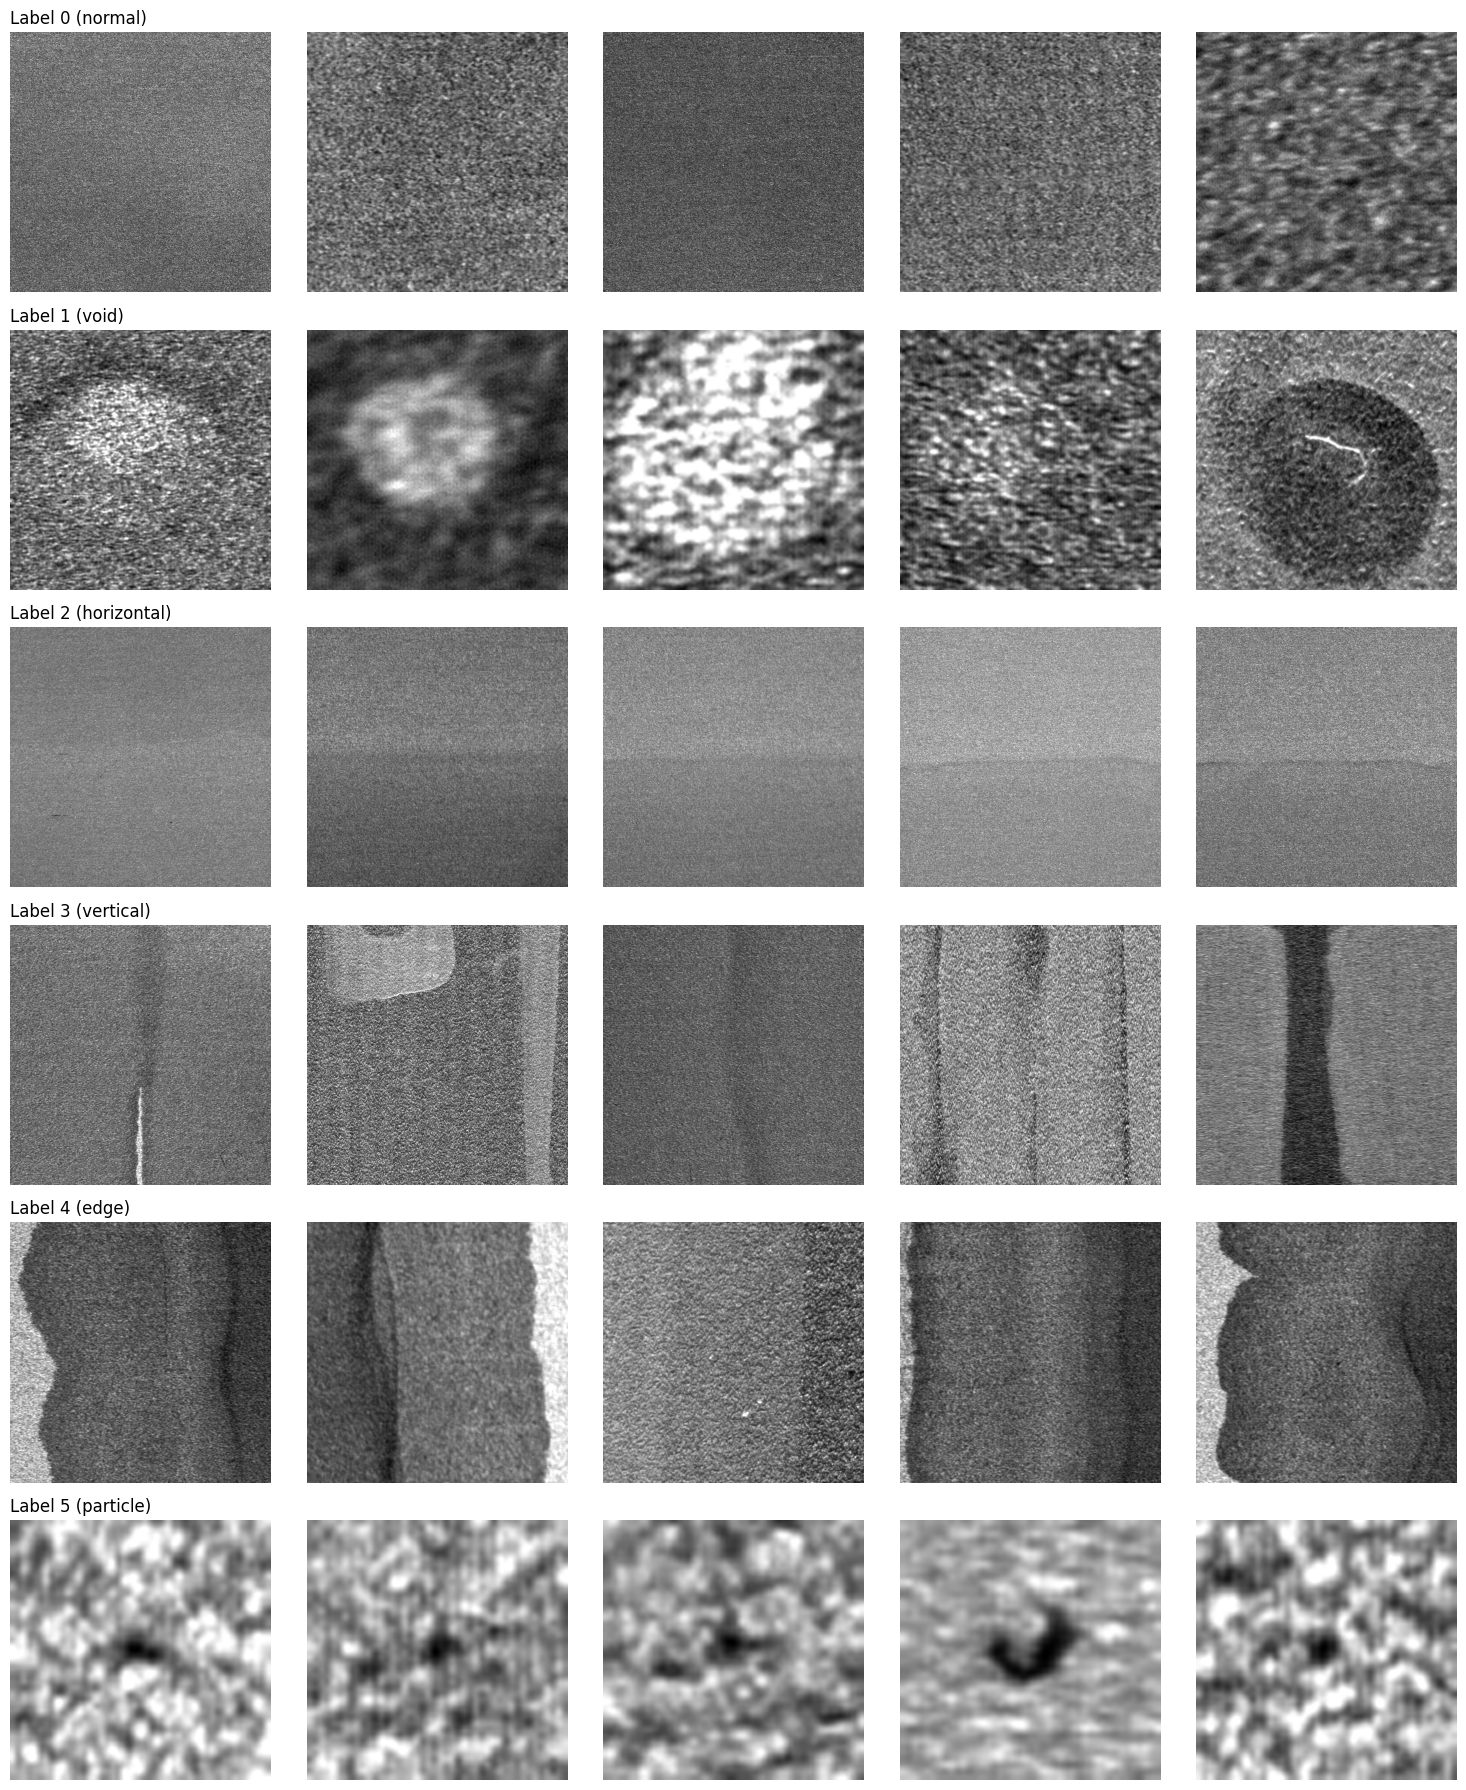

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
names = {0:'normal', 1:'void', 2:'horizontal', 3:'vertical', 4:'edge', 5:'particle'}
for lbl in range(6):
    ids = train_df[train_df['Label'] == lbl]['ID'].head(5).values
    for j, fname in enumerate(ids):
        axes[lbl, j].imshow(Image.open(f'/content/data/train_images/{fname}'), cmap='gray')
        axes[lbl, j].axis('off')
    axes[lbl, 0].set_title(f'Label {lbl} ({names[lbl]})', loc='left')
plt.tight_layout()
plt.savefig('/content/aoi-defect-classification/results/sample_grid.png', dpi=100)
plt.show()

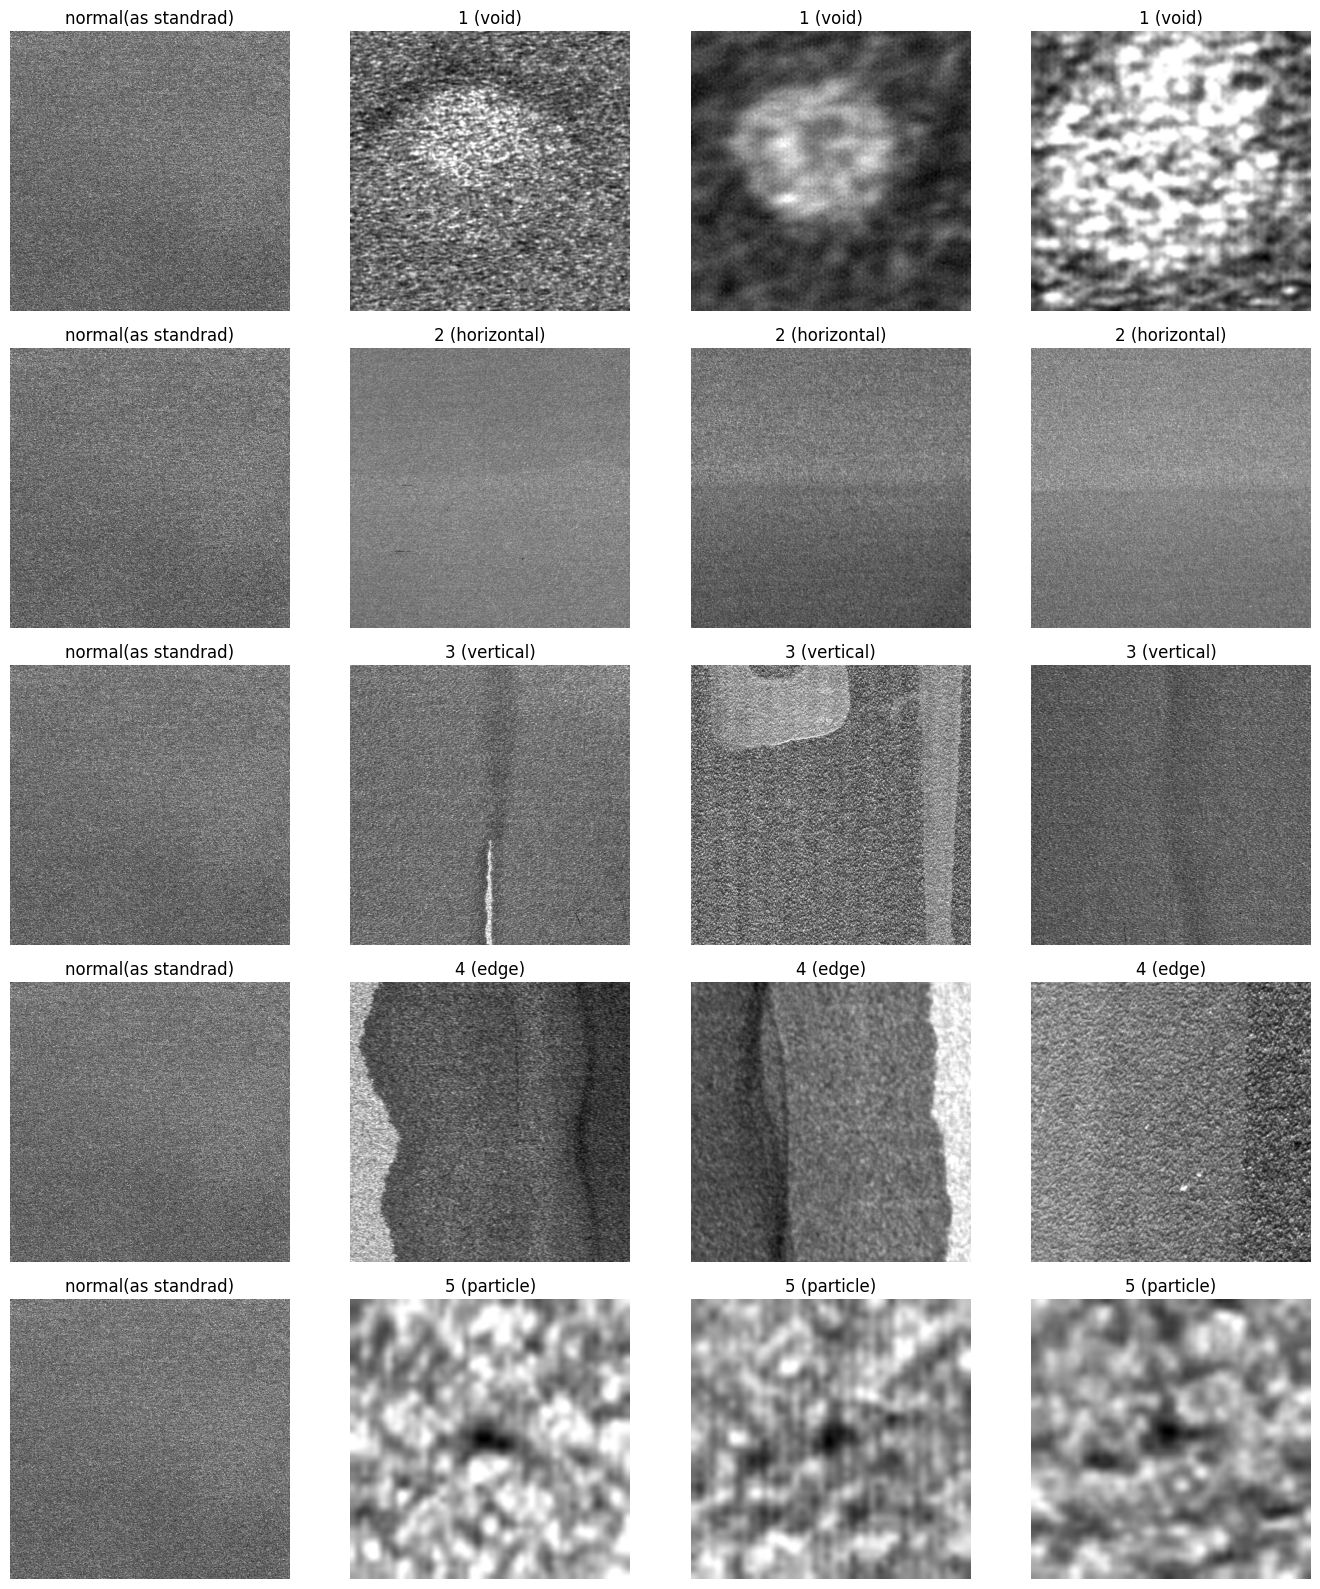

In [ ]:
# 因為我覺得分不太出來標準跟其他瑕疵之間的差異，所以放了normal當基準去跟每個瑕疵做比較
names = {0:'normal', 1:'void', 2:'horizontal', 3:'vertical', 4:'edge', 5:'particle'}

# 左邊固定放一張 normal 當基準,右邊放各種瑕疵
fig, axes = plt.subplots(5, 4, figsize=(14, 16))
normal_ids = train_df[train_df['Label']==0]['ID'].head(1).values[0]
normal_img = Image.open(f'/content/data/train_images/{normal_ids}')

for row, lbl in enumerate([1, 2, 3, 4, 5]):
    # 第一欄:永遠放同一張 normal
    axes[row, 0].imshow(normal_img, cmap='gray')
    axes[row, 0].set_title('normal(as standrad)')
    axes[row, 0].axis('off')
    # 後三欄:這一類的瑕疵
    ids = train_df[train_df['Label']==lbl]['ID'].head(3).values
    for j, fname in enumerate(ids):
        axes[row, j+1].imshow(Image.open(f'/content/data/train_images/{fname}'), cmap='gray')
        axes[row, j+1].set_title(f'{lbl} ({names[lbl]})')
        axes[row, j+1].axis('off')
plt.tight_layout()
plt.show()

## EDA 小結

**資料規模**
- 2528 張標註影像,6 類(0 normal / 1 void / 2 horizontal / 3 vertical / 4 edge / 5 particle)
- 影像規格統一:512×512、灰階(L 模式),無尺寸例外

**類別分布**
- 輕度不平衡,最多/最少約 6.7:1
- class 2(horizontal)僅 100 張,為最少數;驗證集中樣本過少,其指標波動需謹慎解讀

**資料品質**
- 下載時產生 39 個重複檔(檔名帶 " (1)"),已從來源刪除
- 結論:影像清單一律以 train.csv 為準,不掃資料夾,避免重複檔或未標註檔混入

**影像觀察與 domain 約束**
- class 2 與 class 3 為同類瑕疵、僅方向不同(水平 vs 垂直)
  → 禁止水平/垂直翻轉與 90° 旋轉,否則會破壞標籤語意
- class 4(edge defect)以肉眼難以辨識,標註仰賴領域知識;
  預期模型於此類表現值得特別關注,待 confusion matrix 驗證
- 瑕疵在畫面中大致明顯,baseline 先採 224 解析度應足夠

**baseline 決策**
- 灰階轉 3 通道以套用 ImageNet 預訓練權重
- 輸入 resize 至 224×224
- 解析度、通道處理方式等留待第三階段以實驗驗證